# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch1 2026-2027 — Major Project**

This notebook analyzes a seasonal agriculture performance dataset covering **4,000 farm-level records**
across **8 Indian states**, **8 crops**, and **3 seasons** (Kharif, Rabi, Zaid). The goal is to identify
meaningful seasonal patterns, trends, relationships and differences in agricultural performance, and to
develop evidence-based, data-driven recommendations.

**Contents**
1. Import Libraries & Load Data
2. Dataset Overview
3. Data Cleaning & Preparation
4. Exploratory Data Analysis (Seasonal Comparisons)
5. Relationships Between Variables (Correlation Analysis)
6. Crop & State Level Insights
7. Key Findings
8. Conclusions & Recommendations


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#21295C'
plt.rcParams['text.color'] = '#21295C'
plt.rcParams['xtick.color'] = '#21295C'
plt.rcParams['ytick.color'] = '#21295C'
plt.rcParams['font.size'] = 12

pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Dataset Overview

The dataset contains 28 columns covering:
- **Identifiers**: Farm_ID, State, District, Crop, Season
- **Environmental conditions**: Rainfall_mm, Avg_Temperature_C, Humidity_pct, Sunlight_Hours_Day, Soil_pH, Soil_Moisture_pct
- **Farm inputs**: Nitrogen/Phosphorus/Potassium_kg_ha, Irrigation_Method, Fertilizer_kg_ha, Pesticide_Litre_ha, Seed_Quality_Score
- **Outcomes**: Yield_Tonnes_Ha, Production_Tonnes, Market_Price_INR_Tonne, Total_Cost_INR, Revenue_INR, Profit_INR, Water_Used_m3, Water_Efficiency_t_per_1000m3, Disease_Pest_Risk_pct


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [5]:
# Check for missing values
df.isnull().sum()[df.isnull().sum() > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [6]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Basic category counts
print("\nSeasons:\n", df['Season'].value_counts())
print("\nStates:", df['State'].nunique(), "| Crops:", df['Crop'].nunique())
print("\nIrrigation methods:", df['Irrigation_Method'].unique())


Duplicate rows: 0

Seasons:
 Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

States: 8 | Crops: 8

Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning & Preparation

Three columns have missing values: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`.
Since these are numeric and seasonal/crop-dependent, missing values are imputed with the
**median of their own Season (and Crop, for Yield)** group rather than a single global median,
so seasonal patterns are preserved.


In [7]:
season_order = ['Kharif', 'Rabi', 'Zaid']

df['Rainfall_mm'] = df.groupby('Season')['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df['Soil_Moisture_pct'] = df.groupby('Season')['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df['Yield_Tonnes_Ha'] = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [8]:
# Colour palette used consistently across all charts (matches the submission PPT theme)
COLORS = {'Kharif': '#1C7293', 'Rabi': '#21295C', 'Zaid': '#F2A541'}
palette = [COLORS[s] for s in season_order]

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#E5E9F0', linewidth=1)
    ax.grid(axis='x', visible=False)


## 4. Exploratory Data Analysis — Seasonal Comparisons

### 4.1 Average Crop Yield by Season

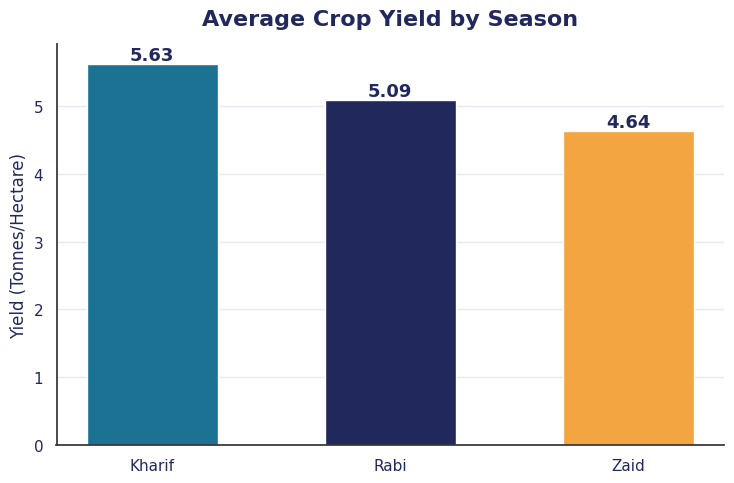

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5))
g = df.groupby('Season')['Yield_Tonnes_Ha'].mean().reindex(season_order)
bars = ax.bar(g.index, g.values, color=palette, width=0.55)
for b, v in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha='center', fontsize=13, fontweight='bold', color='#21295C')
ax.set_title("Average Crop Yield by Season", fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel("Yield (Tonnes/Hectare)")
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/01_avg_yield_by_season.png", dpi=200)
plt.show()


**Observation:** Kharif records the highest average yield, followed by Rabi and then Zaid.

### 4.2 Average Profit by Season

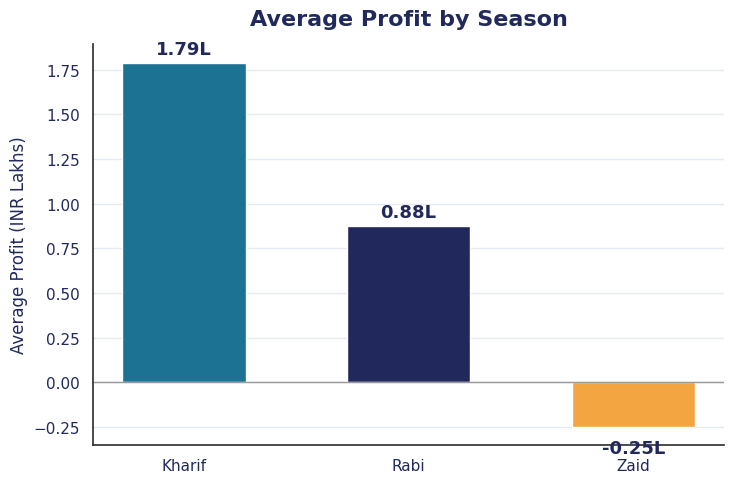

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
g = (df.groupby('Season')['Profit_INR'].mean() / 100000).reindex(season_order)
bars = ax.bar(g.index, g.values, color=palette, width=0.55)
for b, v in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, v + (0.05 if v >= 0 else -0.15), f"{v:.2f}L", ha='center', fontsize=13, fontweight='bold', color='#21295C')
ax.axhline(0, color='#999999', linewidth=1)
ax.set_title("Average Profit by Season", fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel("Average Profit (INR Lakhs)")
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/02_avg_profit_by_season.png", dpi=200)
plt.show()


**Observation:** Kharif is the most profitable season on average; Zaid runs at a slight average loss.

### 4.3 Seasonal Environmental Conditions (Rainfall & Temperature)

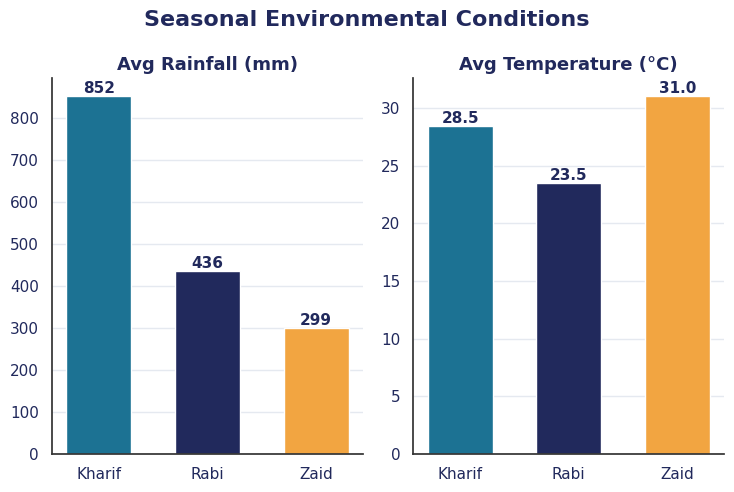

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 5))
g1 = df.groupby('Season')['Rainfall_mm'].mean().reindex(season_order)
g2 = df.groupby('Season')['Avg_Temperature_C'].mean().reindex(season_order)

bars1 = axes[0].bar(g1.index, g1.values, color=palette, width=0.6)
for b, v in zip(bars1, g1.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 8, f"{v:.0f}", ha='center', fontsize=11, fontweight='bold', color='#21295C')
axes[0].set_title("Avg Rainfall (mm)", fontsize=13, fontweight='bold')
style_ax(axes[0])

bars2 = axes[1].bar(g2.index, g2.values, color=palette, width=0.6)
for b, v in zip(bars2, g2.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.1f}", ha='center', fontsize=11, fontweight='bold', color='#21295C')
axes[1].set_title("Avg Temperature (\u00b0C)", fontsize=13, fontweight='bold')
style_ax(axes[1])

fig.suptitle("Seasonal Environmental Conditions", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("outputs/charts/03_rainfall_temp_by_season.png", dpi=200)
plt.show()


**Observation:** Kharif receives far more rainfall than Rabi or Zaid; Zaid is the hottest season.

### 4.4 Water Use Efficiency by Season

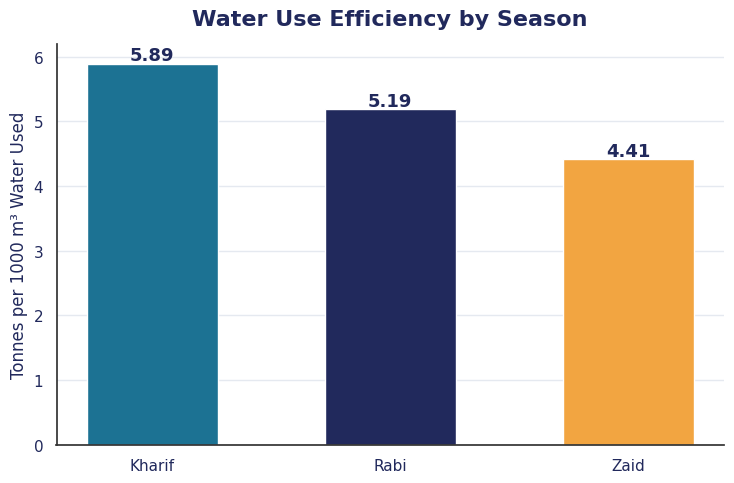

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
g = df.groupby('Season')['Water_Efficiency_t_per_1000m3'].mean().reindex(season_order)
bars = ax.bar(g.index, g.values, color=palette, width=0.55)
for b, v in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.05, f"{v:.2f}", ha='center', fontsize=13, fontweight='bold', color='#21295C')
ax.set_title("Water Use Efficiency by Season", fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel("Tonnes per 1000 m\u00b3 Water Used")
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/04_water_efficiency_by_season.png", dpi=200)
plt.show()


**Observation:** Kharif farms use water most efficiently; Zaid is the least efficient, likely due to higher evaporation in hotter, drier conditions.

### 4.5 Disease & Pest Risk by Season

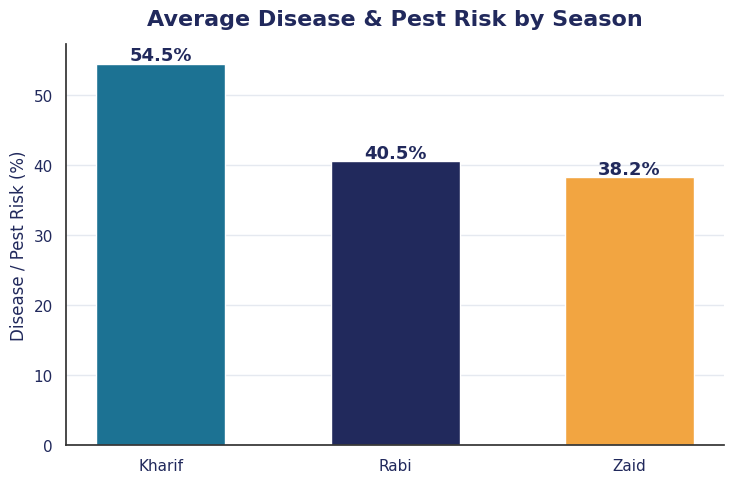

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 5))
g = df.groupby('Season')['Disease_Pest_Risk_pct'].mean().reindex(season_order)
bars = ax.bar(g.index, g.values, color=palette, width=0.55)
for b, v in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha='center', fontsize=13, fontweight='bold', color='#21295C')
ax.set_title("Average Disease & Pest Risk by Season", fontsize=16, fontweight='bold', pad=14)
ax.set_ylabel("Disease / Pest Risk (%)")
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/05_disease_risk_by_season.png", dpi=200)
plt.show()


**Observation:** Disease and pest risk is highest in Kharif, consistent with its higher rainfall and humidity levels.

### 4.6 Average Yield by Crop and Season (Heatmap)

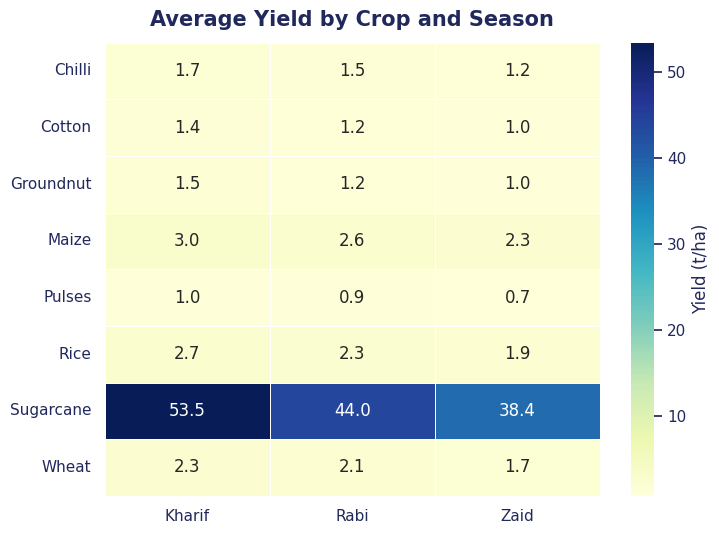

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
pivot = df.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha', aggfunc='mean')[season_order]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax,
            cbar_kws={'label': 'Yield (t/ha)'}, linewidths=0.5, linecolor='white')
ax.set_title("Average Yield by Crop and Season", fontsize=15, fontweight='bold', pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("outputs/charts/06_yield_crop_season_heatmap.png", dpi=200)
plt.show()


**Observation:** Sugarcane records the highest yield across all three seasons among the 8 crops studied.

## 5. Relationships Between Variables — Correlation Analysis

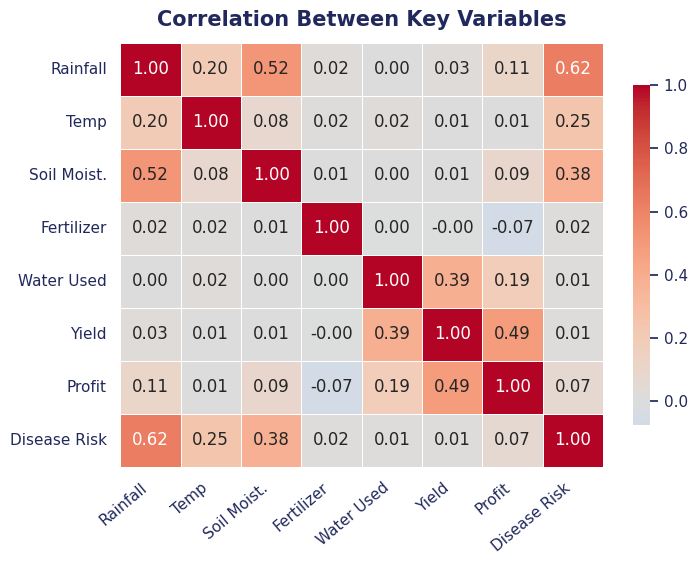

In [15]:
cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Soil_Moisture_pct', 'Fertilizer_kg_ha',
        'Water_Used_m3', 'Yield_Tonnes_Ha', 'Profit_INR', 'Disease_Pest_Risk_pct']
labels = ['Rainfall', 'Temp', 'Soil Moist.', 'Fertilizer', 'Water Used', 'Yield', 'Profit', 'Disease Risk']

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 5.8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            xticklabels=labels, yticklabels=labels, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
ax.set_title("Correlation Between Key Variables", fontsize=15, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig("outputs/charts/07_correlation_heatmap.png", dpi=200)
plt.show()


**Observations:**
- Yield and Profit are moderately positively correlated (**0.49**) — higher yield generally drives higher profit.
- Rainfall and Disease/Pest Risk move together (**0.62**) — wetter conditions raise disease pressure.
- Fertilizer usage shows almost no correlation with Yield or Profit, suggesting usage may not be optimized to actual crop needs.


### 5.1 Irrigation Method Usage by Season

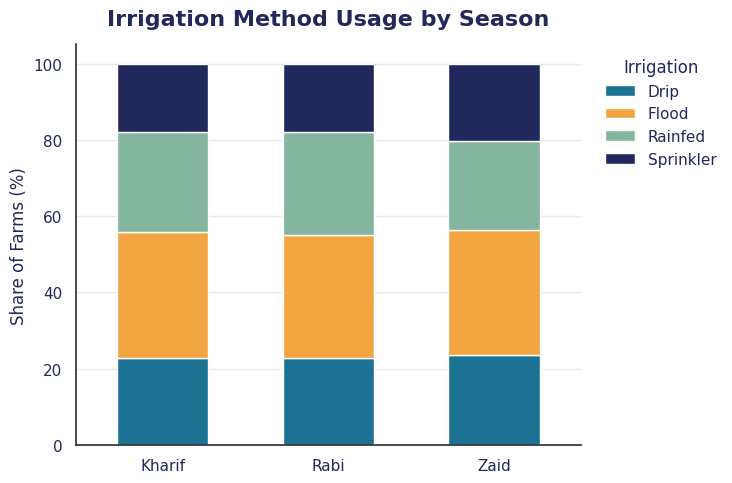

In [16]:
ct = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').reindex(season_order) * 100
irr_colors = ['#1C7293', '#F2A541', '#84B59F', '#21295C']

fig, ax = plt.subplots(figsize=(7.5, 5))
ct.plot(kind='bar', stacked=True, ax=ax, color=irr_colors, width=0.55)
ax.set_ylabel("Share of Farms (%)")
ax.set_xlabel("")
ax.set_title("Irrigation Method Usage by Season", fontsize=16, fontweight='bold', pad=14)
plt.xticks(rotation=0)
ax.legend(title="Irrigation", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/08_irrigation_distribution.png", dpi=200)
plt.show()


**Observation:** Flood irrigation is the most-used method (~33%) consistently across all three seasons, followed by rainfed, drip, and sprinkler.

## 6. Crop & State Level Insights

### 6.1 Average Cost, Revenue & Profit by Season

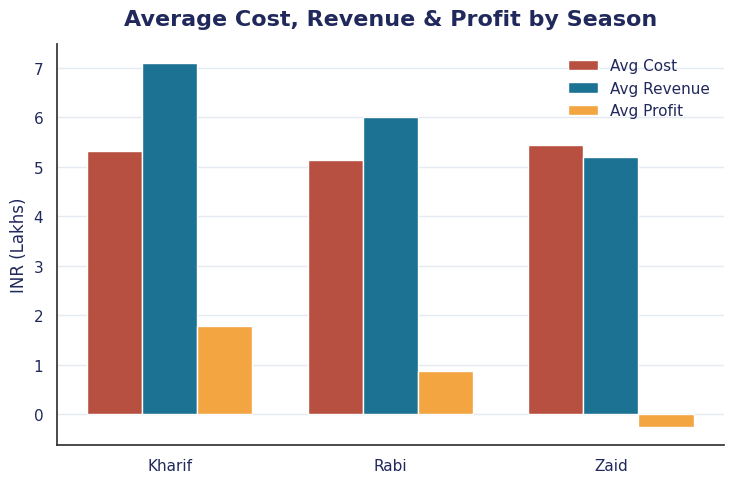

In [17]:
g = df.groupby('Season')[['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']].mean().reindex(season_order) / 100000
x = np.arange(len(season_order))
w = 0.25

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.bar(x - w, g['Total_Cost_INR'], width=w, label='Avg Cost', color='#B85042')
ax.bar(x, g['Revenue_INR'], width=w, label='Avg Revenue', color='#1C7293')
ax.bar(x + w, g['Profit_INR'], width=w, label='Avg Profit', color='#F2A541')
ax.set_xticks(x); ax.set_xticklabels(season_order)
ax.set_ylabel("INR (Lakhs)")
ax.set_title("Average Cost, Revenue & Profit by Season", fontsize=16, fontweight='bold', pad=14)
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.savefig("outputs/charts/09_cost_revenue_profit.png", dpi=200)
plt.show()


**Observation:** Kharif shows the highest average cost, revenue and profit among the three seasons.

### 6.2 Top 5 States by Average Profit

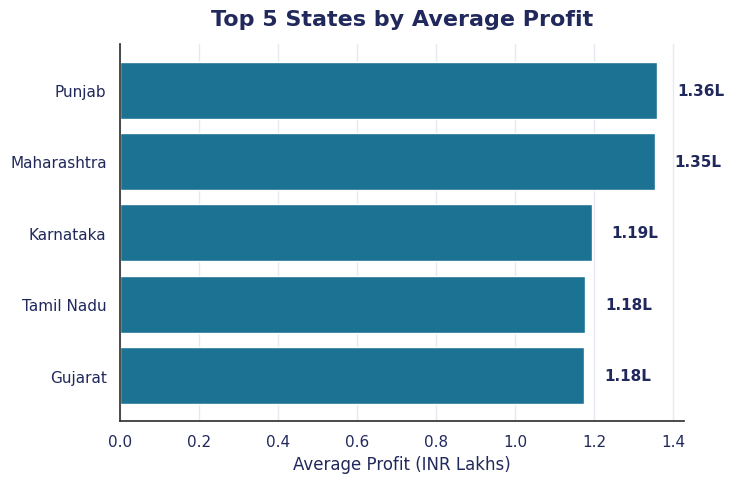

In [18]:
g = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).head(5) / 100000

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.barh(g.index[::-1], g.values[::-1], color='#1C7293')
for b, v in zip(bars, g.values[::-1]):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2, f"{v:.2f}L", va='center', fontsize=11, fontweight='bold', color='#21295C')
ax.set_title("Top 5 States by Average Profit", fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel("Average Profit (INR Lakhs)")
style_ax(ax)
ax.grid(axis='x', color='#E5E9F0'); ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.savefig("outputs/charts/10_top_states_profit.png", dpi=200)
plt.show()


**Observation:** Punjab, Maharashtra and Karnataka top the average-profit rankings among the 8 states studied.

In [19]:
# Additional summary table used for reference
summary = df.groupby('Season').agg(
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean'),
).reindex(season_order).round(2)
summary


,Avg_Yield_t_ha,Avg_Profit_INR,Avg_Rainfall_mm,Avg_Temp_C,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,
Kharif,5.63,178914.65,852.11,28.45,5.89,54.47
Rabi,5.09,87689.47,435.94,23.49,5.19,40.48
Zaid,4.64,-24804.82,299.12,31.04,4.41,38.22


## 7. Key Findings

1. **Kharif is the best-performing season overall** — highest average yield (5.63 t/ha), highest profit (₹1.79L), and highest water-use efficiency (5.89 t/1000m³), backed by the highest rainfall (852mm).
2. **Zaid is the weakest season** — lowest yield (4.64 t/ha) and runs at a small average **loss** (-₹0.25L), driven by high temperatures (31°C) and lower rainfall (299mm).
3. **Disease/Pest risk tracks rainfall** (correlation 0.62) — Kharif's higher rainfall brings higher pest/disease pressure (54.5% vs ~38-40% in Rabi/Zaid), partly offsetting its yield advantage.
4. **Sugarcane is the top-yielding crop** in every single season among the 8 crops studied.
5. **Flood irrigation dominates** (~33% of farms) in all three seasons, with drip and sprinkler still a minority — an opportunity for efficiency gains.
6. **Fertilizer usage shows almost no correlation with yield or profit** (~0.00 / -0.07), suggesting fertilizer application may not be well-matched to actual seasonal or crop needs.
7. **Punjab, Maharashtra, and Karnataka** are the most profitable states on average.
8. Nearly **49% of all farm records show a negative profit**, indicating cost control is a widespread issue, not limited to one season or crop.


## 8. Conclusions & Recommendations

- **Season-specific planning matters**: Kharif's advantages (rainfall, yield, profit) come with a real trade-off in disease/pest risk — farmers should combine Kharif planting with proactive pest management (resistant seed varieties, timely pesticide application) to protect margins.
- **Zaid needs cost and water optimization**: Given its low profitability, promoting drip irrigation and heat-tolerant, short-duration crop varieties could improve Zaid-season outcomes.
- **Fertilizer application should be re-evaluated**: Since fertilizer spend doesn't correlate with better yield/profit, soil-test-based, need-based fertilizer recommendations could reduce costs without hurting output.
- **Irrigation modernization**: Shifting a larger share of flood-irrigated farms to drip/sprinkler systems, especially in low-rainfall seasons (Zaid), can raise water-use efficiency.
- **Targeted state-level support**: Best practices from high-profit states (Punjab, Maharashtra, Karnataka) — e.g., crop selection, irrigation mix — could be studied and extended to lower-performing states.
- **Address the near-50% negative-profit rate**: A deeper cost-breakdown study (input cost vs. market price volatility) is recommended as a priority follow-up analysis.

*See the "Future Scope" section of the accompanying presentation for planned extensions (predictive modelling, real-time weather integration, interactive dashboards, and market-price forecasting).*
